In [26]:
import torch
import torch.nn as nn
import time

In [27]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs/vae_'+time.strftime("%Y%m%d-%H%M%S"))

In [28]:
device = torch.device("cpu")
  # for nvidia gpu ( cuda backend )
if (torch.cuda.is_available()):
    device = torch.device("cuda")
  # mps for apple M GPU ( metal backend )
elif (torch.backends.mps.is_available()):
    device = torch.device("mps")

print("Using device:", device)

Using device: mps


In [29]:
#hyerparameters

batch_size = 100
x_dim = 784
hidden_dim = 256
latent_dim = 64
lr = 1e-3
epochs = 20

In [30]:
import model

vae = model.VAE(
    encoder = nn.Sequential(
        nn.Linear(x_dim, 512),
        nn.LeakyReLU(0.2),
        nn.Linear(512, 256),
        nn.LeakyReLU(0.2),
    ),
    decoder = nn.Sequential(
        nn.Linear(latent_dim, 256),
        nn.LeakyReLU(0.2),
        nn.Linear(256, x_dim),
        nn.Sigmoid()
    ),
    mean=nn.Linear(256, latent_dim),
    var= nn.Linear(256, latent_dim)
).to(device)

VAE model initialized


In [31]:
MSE = nn.MSELoss().to(device)
def loss_function(x,x_hat,mu,var):
    rec_loss = MSE(x_hat, x)
    kl_loss = -0.0001 * torch.sum(1 + var - mu.pow(2) - var.exp())
    return rec_loss, kl_loss

In [32]:
from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

dataset_path = './data/'

mnist_transform = transforms.Compose([
    transforms.ToTensor(),transforms.Normalize((0.1307,), (0.3081,))
])

kwargs = {'num_workers': 1, 'pin_memory': True}

train_dataset = MNIST(
    dataset_path, transform=mnist_transform, train=True, download=True)
test_dataset = MNIST(dataset_path, transform=mnist_transform,
                     train=False, download=True)

train_loader = DataLoader(dataset=train_dataset,
                          batch_size=batch_size, shuffle=True, **kwargs)
test_loader = DataLoader(dataset=test_dataset,
                         batch_size=batch_size, shuffle=False, **kwargs)

In [33]:
from torch.optim import Adam

opt = Adam(vae.parameters(), lr=lr)

vae.train()

for epoch in range(epochs):
    overall_loss = 0
    overall_mse = 0
    overall_kl = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(batch_size, x_dim)
        x = x.to(device)
        opt.zero_grad()
        z, mu, var, encoder_outputs, decoder_outputs = vae(x)
    
        rec_loss, kl_loss = loss_function(x, decoder_outputs, mu, var)
        
        loss = rec_loss + kl_loss
        overall_mse += rec_loss.item()
        overall_kl += kl_loss.item()
        overall_loss += loss.item()
        loss.backward()
        opt.step()

    writer.add_scalar('Loss/total', overall_loss / ((batch_idx+1)*batch_size), epoch)
    writer.add_scalar('Loss/mse', overall_mse / ((batch_idx+1)*batch_size), epoch)
    writer.add_scalar('Loss/kl', overall_kl / ((batch_idx+1)*batch_size), epoch)
    
    print("\tEpoch", epoch + 1, "complete!", "\tAverage Loss: ",
          overall_loss / ((batch_idx+1)*batch_size), "\tAverage MSE: ", overall_mse / ((batch_idx+1)*batch_size), "\tAverage KL: ", overall_kl / ((batch_idx+1)*batch_size))

print("Finish!!")

	Epoch 1 complete! 	Average Loss:  0.008057005443175634 	Average MSE:  0.007852261611819268 	Average KL:  0.00020474383335871002
	Epoch 2 complete! 	Average Loss:  0.007587776532769203 	Average MSE:  0.007171389404932658 	Average KL:  0.00041638713454206786
	Epoch 3 complete! 	Average Loss:  0.007497525994976361 	Average MSE:  0.006995566822091738 	Average KL:  0.0005019591777275006
	Epoch 4 complete! 	Average Loss:  0.007424968435366949 	Average MSE:  0.006866203770041466 	Average KL:  0.0005587646583716075
	Epoch 5 complete! 	Average Loss:  0.007394673374295235 	Average MSE:  0.00681294408539931 	Average KL:  0.0005817292905102173
	Epoch 6 complete! 	Average Loss:  0.00737475749651591 	Average MSE:  0.0067777350058158235 	Average KL:  0.0005970224924385548
	Epoch 7 complete! 	Average Loss:  0.007356376646955808 	Average MSE:  0.00674895940721035 	Average KL:  0.0006074172357097268
	Epoch 8 complete! 	Average Loss:  0.007341203601161639 	Average MSE:  0.006722225533922513 	Average KL:

In [34]:
import matplotlib.pyplot as plt

vae.eval()

with torch.no_grad():
    for batch_idx, (x, _) in enumerate(test_loader):
        x = x.view(batch_size, x_dim)
        x = x.to(device)

        _, _, _, _, x_hat = vae(x)

        break

In [35]:
def show_image(x, idx):
    x = x.view(batch_size, 28, 28)
    fig = plt.figure()
    plt.imshow(x[idx].cpu().numpy())

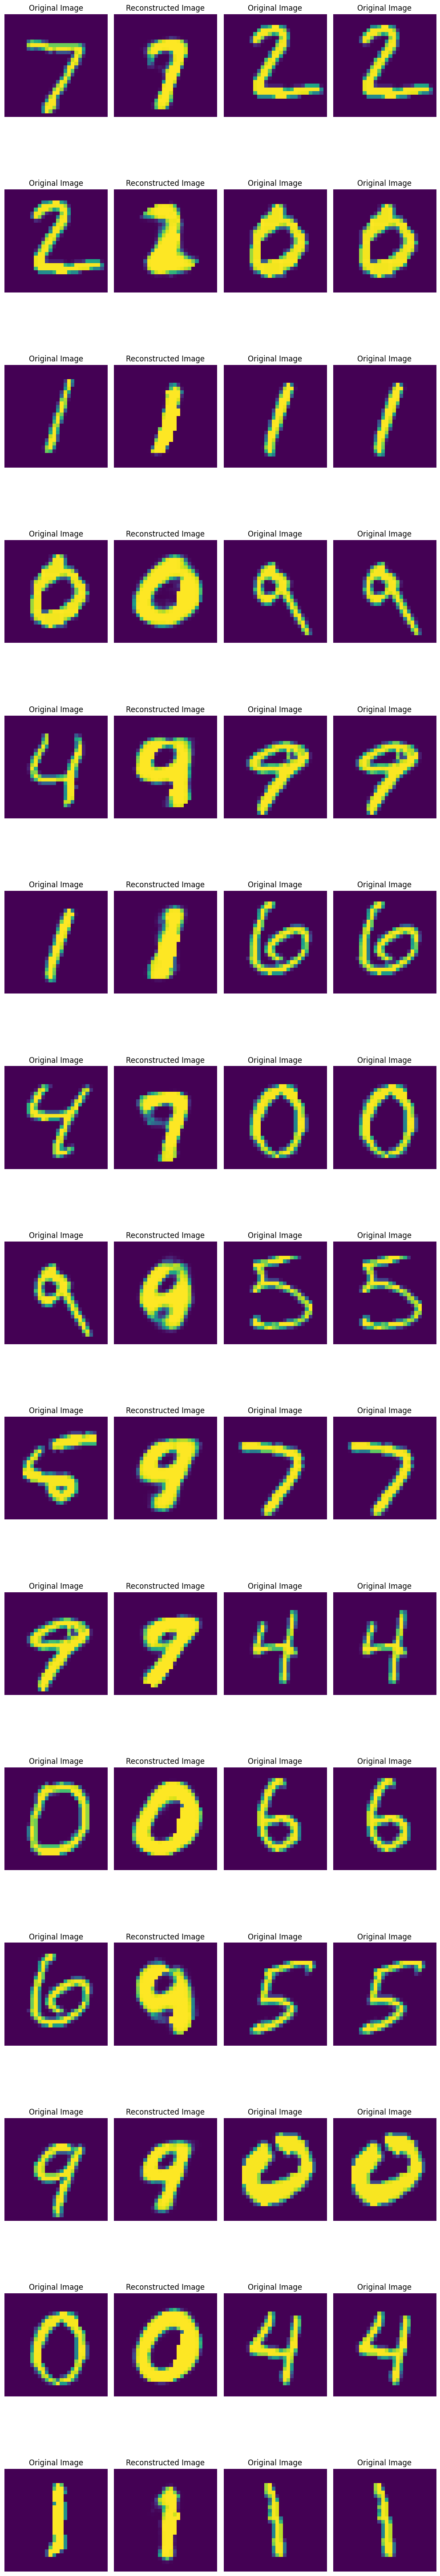

In [57]:

# make gap smaller 
fig, axes = plt.subplots(nrows=15, ncols=4, figsize=(10, 60))

for i in range(15):

    original_image = x[i].view(28, 28).cpu().numpy()
    reconstructed_image = x_hat[i].view(28, 28).cpu().numpy()
    
    axes[i, 0].imshow(original_image)
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(reconstructed_image)
    axes[i, 1].set_title('Reconstructed Image')
    axes[i, 1].axis('off')
    j = i*2+1
    original_image = x[j].view(28, 28).cpu().numpy()
    reconstructed_image = x_hat[j].view(28, 28).cpu().numpy()

    # Add your own images or modify as per your requirement
    axes[i, 2].imshow(original_image)
    axes[i, 2].set_title('Original Image')
    axes[i, 2].axis('off')

    axes[i, 3].imshow(original_image)
    axes[i, 3].set_title('Original Image')
    axes[i, 3].axis('off')

plt.tight_layout()
plt.show()